# Casualty Dataset — Exploratory Data Analysis

This notebook performs exploratory data analysis on the Casualty dataset from the UK STATS19 road safety data.

The analysis focuses on understanding the structure, distributions, missing values, coded categories, unusual values, and potential data-quality issues in the casualty-level records.

No data cleaning, aggregation, feature engineering, or dataset integration is performed during this EDA stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


casualty_df = pd.read_csv(
    "../data/dft-road-casualty-statistics-casualty-last-5-years.csv"
)

print("Shape:", casualty_df.shape)
display(casualty_df.head())

Shape: (652821, 23)


,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2021010287661,2021,010287661,1,1,3,1,50,8,3,...,0,0,0,-1,-1,-1,0,0.0,1.0,-1
1,2021010293865,2021,010293865,1,1,3,1,35,6,3,...,0,0,0,2,E01001509,-1,0,0.0,1.0,-1
2,2021010298600,2021,010298600,1,1,3,1,6,2,3,...,0,0,0,9,E01003418,-1,0,0.0,1.0,-1
3,2021010302619,2021,010302619,1,1,3,1,41,7,3,...,0,0,0,7,E01001882,-1,0,0.0,1.0,-1
4,2021010304568,2021,010304568,1,1,3,1,11,3,3,...,0,0,0,2,E01000027,-1,0,0.0,1.0,-1


In [2]:
casualty_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 652821 entries, 0 to 652820
Data columns (total 23 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   collision_index                     652821 non-null  str    
 1   collision_year                      652821 non-null  int64  
 2   collision_ref_no                    652821 non-null  str    
 3   vehicle_reference                   652821 non-null  int64  
 4   casualty_reference                  652821 non-null  int64  
 5   casualty_class                      652821 non-null  int64  
 6   sex_of_casualty                     652821 non-null  int64  
 7   age_of_casualty                     652821 non-null  int64  
 8   age_band_of_casualty                652821 non-null  int64  
 9   casualty_severity                   652821 non-null  int64  
 10  pedestrian_location                 652821 non-null  int64  
 11  pedestrian_movement                 6

In [3]:
print("Number of rows:", casualty_df.shape[0])
print("Number of columns:", casualty_df.shape[1])

print("\nColumn Names:")
for i, column in enumerate(casualty_df.columns, start=1):
    print(f"{i}. {column}")

Number of rows: 652821
Number of columns: 23

Column Names:
1. collision_index
2. collision_year
3. collision_ref_no
4. vehicle_reference
5. casualty_reference
6. casualty_class
7. sex_of_casualty
8. age_of_casualty
9. age_band_of_casualty
10. casualty_severity
11. pedestrian_location
12. pedestrian_movement
13. car_passenger
14. bus_or_coach_passenger
15. pedestrian_road_maintenance_worker
16. casualty_type
17. casualty_imd_decile
18. lsoa_of_casualty
19. enhanced_casualty_severity
20. casualty_injury_based
21. casualty_adjusted_severity_serious
22. casualty_adjusted_severity_slight
23. casualty_distance_banding


In [4]:
print("Unique collision_index:",
      casualty_df["collision_index"].nunique())

print("Unique collision_ref_no:",
      casualty_df["collision_ref_no"].nunique())

print("Unique casualty_reference:",
      casualty_df["casualty_reference"].nunique())

Unique collision_index: 513801
Unique collision_ref_no: 510837
Unique casualty_reference: 145


## 1. Basic Overview Findings

The Casualty dataset contains **652,821 records and 23 variables**.
Each record represents a casualty involved in a reported collision.

The dataset contains no actual `NaN` values across its 23 variables.
The identifier fields `collision_index` and `collision_ref_no` are
stored as strings, while most coded variables are stored as integers.

The dataset contains **513,801 unique `collision_index` values**,
indicating that multiple casualty records can belong to the same
collision.

The `casualty_reference` field contains 145 unique values and should
therefore not be treated as a globally unique identifier. It identifies
casualties within the relevant collision/vehicle structure.

The main identifier and relationship fields are:

- `collision_index` — links the casualty record to a collision.
- `vehicle_reference` — identifies the vehicle associated with the
  casualty within the collision.
- `casualty_reference` — identifies the casualty within the relevant
  collision/vehicle structure.

The dataset also contains demographic, casualty classification,
pedestrian, passenger, severity, socioeconomic, and distance-related
variables.

No data cleaning, transformation, aggregation, or integration is
performed during this step.

## 2. Descriptive Statistics

Descriptive statistics are used to examine the distribution, central
tendency, and range of the variables in the Casualty dataset.

Because many Casualty variables are stored as integer-coded categories,
their statistical values such as mean and standard deviation are not
interpreted as continuous measurements.

The descriptive statistics are therefore used mainly to identify the
range, unusual values, and variables requiring further categorical
analysis.

In [5]:
casualty_df.describe().T

,count,mean,std,min,25%,50%,75%,max
collision_year,652821.0,2022.987960,1.404641,2021.0,2022.00000,2023.0,2024.00000,2025.0
vehicle_reference,652821.0,1.445614,2.228090,1.0,1.00000,1.0,2.00000,992.0
casualty_reference,652821.0,1.358939,2.323973,1.0,1.00000,1.0,1.00000,999.0
casualty_class,652821.0,1.481504,0.734070,1.0,1.00000,1.0,2.00000,3.0
sex_of_casualty,652821.0,1.362879,0.547908,-1.0,1.00000,1.0,2.00000,9.0
age_of_casualty,652821.0,37.157120,19.855376,-1.0,22.00000,34.0,51.00000,105.0
age_band_of_casualty,652821.0,6.341843,2.485142,-1.0,5.00000,6.0,8.00000,11.0
casualty_severity,652821.0,2.777769,0.444359,1.0,3.00000,3.0,3.00000,3.0
pedestrian_location,652821.0,0.797837,2.197424,-1.0,0.00000,0.0,0.00000,10.0
pedestrian_movement,652821.0,0.648400,2.019000,-1.0,0.00000,0.0,0.00000,9.0


In [6]:
casualty_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
collision_index,652821,513801,2025052501204,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collision_year,652821.0,NaN,NaN,NaN,2022.98796,1.404641,2021.0,2022.0,2023.0,2024.0,2025.0
collision_ref_no,652821,510837,052501204,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_reference,652821.0,NaN,NaN,NaN,1.445614,2.22809,1.0,1.0,1.0,2.0,992.0
casualty_reference,652821.0,NaN,NaN,NaN,1.358939,2.323973,1.0,1.0,1.0,1.0,999.0
casualty_class,652821.0,NaN,NaN,NaN,1.481504,0.73407,1.0,1.0,1.0,2.0,3.0
sex_of_casualty,652821.0,NaN,NaN,NaN,1.362879,0.547908,-1.0,1.0,1.0,2.0,9.0
age_of_casualty,652821.0,NaN,NaN,NaN,37.15712,19.855376,-1.0,22.0,34.0,51.0,105.0
age_band_of_casualty,652821.0,NaN,NaN,NaN,6.341843,2.485142,-1.0,5.0,6.0,8.0,11.0
casualty_severity,652821.0,NaN,NaN,NaN,2.777769,0.444359,1.0,3.0,3.0,3.0,3.0


In [7]:
numerical_candidates = [
    "age_of_casualty"
]

casualty_df[numerical_candidates].describe().T

,count,mean,std,min,25%,50%,75%,max
age_of_casualty,652821.0,37.15712,19.855376,-1.0,22.0,34.0,51.0,105.0


In [8]:
for column in numerical_candidates:
    print(f"\n{'='*60}")
    print(column)
    print(f"{'='*60}")
    
    print("Minimum:", casualty_df[column].min())
    print("Maximum:", casualty_df[column].max())


age_of_casualty
Minimum: -1
Maximum: 105


## 2. Descriptive Statistics Findings

The descriptive statistics show that the Casualty dataset contains
652,821 records covering the period from 2021 to 2025.

Most Casualty variables are stored as integer-coded variables. Their
means and standard deviations therefore do not represent meaningful
continuous measurements and will be interpreted using their categorical
codes and the official DfT data guide in later EDA steps.

The main quantitative variable identified is `age_of_casualty`.

The `age_of_casualty` variable has:

- Mean: **37.16 years**
- Median: **34 years**
- Q1: **22 years**
- Q3: **51 years**
- Minimum: **-1**
- Maximum: **105 years**

The `-1` value requires separate investigation because it represents a
coded value rather than a genuine negative age.

Several reference variables also show large maximum values. For
example, `vehicle_reference` has a maximum of **992** and
`casualty_reference` has a maximum of **999**. These are reference
fields and should not be treated as continuous numerical variables.

The `casualty_severity` variable ranges from **1 to 3**, while several
other variables contain values such as `-1`, `9`, and `99`. These coded
values require variable-specific interpretation using the official DfT
data definitions.

The descriptive statistics therefore provide an initial overview of
the variable ranges and identify fields requiring further categorical
and data-quality investigation. No values are modified or removed at
this stage.

## 3. Categorical Frequency Analysis

Categorical frequency analysis is performed to examine the distribution
of coded categories within the Casualty dataset.

The analysis identifies dominant categories, rare categories, and
special coded values that may require further investigation.

The official DfT data guide is used to interpret the meaning of the
coded values. Codes such as `-1`, `0`, `9`, and `99` are not assumed to
have the same meaning across variables.

No values are modified or removed during this analysis.

In [10]:
categorical_columns = [
    "casualty_class",
    "sex_of_casualty",
    "age_band_of_casualty",
    "casualty_severity",
    "pedestrian_location",
    "pedestrian_movement",
    "car_passenger",
    "bus_or_coach_passenger",
    "pedestrian_road_maintenance_worker",
    "casualty_type",
    "casualty_imd_decile",
    "enhanced_casualty_severity",
    "casualty_injury_based",
    "casualty_distance_banding"
]

for column in categorical_columns:
    print(f"\n{'='*60}")
    print(column)
    print(f"{'='*60}")

    display(
        casualty_df[column]
        .value_counts(dropna=False)
        .to_frame("Count")
    )


casualty_class


,Count
casualty_class,
1,432883
2,125540
3,94398



sex_of_casualty


,Count
sex_of_casualty,
1,397917
2,248471
-1,6304
9,129



age_band_of_casualty


...

,Count
enhanced_casualty_severity,
3,328565
-1,226536
7,55413
6,20082
5,16646
1,5579



casualty_injury_based


,Count
casualty_injury_based,
1,426285
0,226536



casualty_distance_banding


,Count
casualty_distance_banding,
-1,428604
1,126648
2,34916
4,27723
3,27042
5,7888


## 3. Categorical Frequency Analysis

Categorical frequency analysis was performed to examine the distribution
of coded categories in the Casualty dataset.

The variables included in `categorical_columns` represent categorical
or coded classification variables according to the dataset structure and
the official DfT data guide.

The following variables are intentionally excluded from this categorical
frequency analysis:

- `age_of_casualty` — treated separately as a numerical variable.
- `casualty_adjusted_severity_serious` — excluded because the observed
  data contains **24,545 distinct values**, including many fractional
  values between 0 and 1. Therefore, it is not suitable for a standard
  categorical frequency table.
- `casualty_adjusted_severity_slight` — excluded for the same reason;
  the observed data contains **24,545 distinct values**, including many
  fractional values between 0 and 1.

These columns are **not removed from the Casualty dataset**. They remain
in `casualty_df` and can be analyzed separately if required.

The remaining categorical variables were analyzed using frequency
counts. Special values such as `-1`, `9`, and `99` were retained during
EDA because their meanings are variable-specific according to the
official DfT data guide.

### 3.1 Frequency Analysis Results

The frequency analysis identified the following major distributions:

- **`casualty_class`**
  - Code `1`: **432,883** records
  - Code `2`: **125,540** records
  - Code `3`: **94,398** records

- **`sex_of_casualty`**
  - Code `1`: **397,917** records
  - Code `2`: **248,471** records
  - Code `-1`: **6,304** records
  - Code `9`: **129** records

- **`age_band_of_casualty`**
  - Code `6`: **132,804** records
  - Code `7`: **100,841** records
  - Code `8`: **81,997** records
  - Code `5`: **70,305** records
  - Code `-1`: **14,106** records

- **`casualty_severity`**
  - Code `3`: **515,777** records
  - Code `2`: **129,011** records
  - Code `1`: **8,033** records

- **`pedestrian_location`**
  - Code `0`: **558,404** records
  - Code `5`: **34,403** records
  - Code `1`: **15,547** records
  - Code `6`: **12,236** records
  - Code `9`: **9,709** records

- **`pedestrian_movement`**
  - Code `0`: **558,404** records
  - Code `1`: **29,446** records
  - Code `9`: **27,230** records
  - Code `3`: **19,038** records

- **`car_passenger`**
  - Code `0`: **543,028** records
  - Code `1`: **66,488** records
  - Code `2`: **39,700** records
  - Code `-1`: **2,926** records
  - Code `9`: **679** records

- **`bus_or_coach_passenger`**
  - Code `0`: **642,882** records
  - Code `4`: **5,838** records
  - Code `3`: **2,557** records
  - Code `-1`: **515** records

- **`pedestrian_road_maintenance_worker`**
  - Code `0`: **616,155** records
  - Code `-1`: **29,440** records
  - Code `2`: **6,537** records
  - Code `1`: **689** records

- **`casualty_type`**
  - Code `9`: **347,393** records
  - Code `0`: **94,398** records
  - Code `1`: **77,741** records
  - Code `3`: **41,840** records
  - Code `5`: **22,542** records
  - Code `19`: **19,135** records
  - Code `-1`: **5,780** records
  - Code `99`: **33** records

- **`casualty_imd_decile`**
  - Code `-1`: **73,236** records
  - Code `2`: **72,216** records
  - Code `1`: **71,234** records
  - Code `3`: **69,325** records
  - Code `10`: **38,899** records

- **`enhanced_casualty_severity`**
  - Code `3`: **328,565** records
  - Code `-1`: **226,536** records
  - Code `7`: **55,413** records
  - Code `6`: **20,082** records
  - Code `5`: **16,646** records
  - Code `1`: **5,579** records

- **`casualty_injury_based`**
  - Code `1`: **426,285** records
  - Code `0`: **226,536** records

- **`casualty_distance_banding`**
  - Code `-1`: **428,604** records
  - Code `1`: **126,648** records
  - Code `2`: **34,916** records
  - Code `4`: **27,723** records
  - Code `3`: **27,042** records
  - Code `5`: **7,888** records

### 3.2 Key Findings

The frequency analysis shows several important patterns in the Casualty
dataset.

1. **Casualty severity is highly concentrated in code `3`.**
   Code `3` contains **515,777 records**, compared with **129,011**
   records for code `2` and **8,033** records for code `1**.

2. **Several categorical variables contain special coded values.**
   Values such as `-1` and `9` occur in variables including
   `sex_of_casualty`, `age_band_of_casualty`, `car_passenger`,
   `enhanced_casualty_severity`, and `casualty_distance_banding`.

3. **`casualty_distance_banding` contains a particularly large
   proportion of code `-1`**, with **428,604 records**. This requires
   further investigation during the data-quality stage.

4. **`enhanced_casualty_severity` also contains a substantial number of
   `-1` records**, with **226,536 observations**.

5. **`casualty_injury_based` contains two dominant categories**, with
   code `1` occurring **426,285** times and code `0` occurring
   **226,536** times.

6. **`casualty_type` is dominated by code `9`**, with **347,393
   records**, while several other casualty types occur at much lower
   frequencies.

7. The frequency analysis does **not modify or remove any values**.
   The identified special codes and highly concentrated categories will
   be investigated further during the data-quality and preprocessing
   stages.

### 3.3 EDA Boundary

The purpose of this analysis is to understand the distribution of the
categorical variables and identify potential data-quality issues.

No values are removed, replaced, recoded, or imputed during this stage.
The meanings and treatment of special coded values will be determined
during the later data-quality and preprocessing stages using the
variable-specific DfT definitions.

In [11]:
## 4. Categorical Percentage Analysis

for column in categorical_columns:
    print(f"\n{'='*60}")
    print(column)
    print(f"{'='*60}")

    percentage = (
        casualty_df[column]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(2)
    )

    count = casualty_df[column].value_counts(dropna=False)

    summary = pd.DataFrame({
        "Count": count,
        "Percentage": percentage
    })

    display(summary)


casualty_class


,Count,Percentage
casualty_class,,
1,432883,66.31
2,125540,19.23
3,94398,14.46



sex_of_casualty


,Count,Percentage
sex_of_casualty,,
1,397917,60.95
2,248471,38.06
-1,6304,0.97
9,129,0.02



age_band_of_casualty


...

,Count,Percentage
enhanced_casualty_severity,,
3,328565,50.33
-1,226536,34.70
7,55413,8.49
6,20082,3.08
5,16646,2.55
1,5579,0.85



casualty_injury_based


,Count,Percentage
casualty_injury_based,,
1,426285,65.3
0,226536,34.7



casualty_distance_banding


,Count,Percentage
casualty_distance_banding,,
-1,428604,65.65
1,126648,19.40
2,34916,5.35
4,27723,4.25
3,27042,4.14
5,7888,1.21


## 4. Categorical Percentage Analysis

Categorical percentage analysis was performed to determine the proportion
of Casualty records represented by each category.

The percentages were calculated using the total number of Casualty
records (**652,821**).

The category meanings were interpreted using the official DfT data guide.
Special codes such as `-1`, `9`, and `99` were retained because their
meaning is variable-specific.

### 4.1 Categorical Percentage Results

#### `casualty_class`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 1 | Driver or rider | 432,883 | 66.31% |
| 2 | Passenger | 125,540 | 19.23% |
| 3 | Pedestrian | 94,398 | 14.46% |

The majority of casualties are **drivers or riders**, representing
66.31% of all casualty records. Passengers account for 19.23%, while
pedestrians account for 14.46%.

---

#### `sex_of_casualty`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 1 | Male | 397,917 | 60.95% |
| 2 | Female | 248,471 | 38.06% |
| -1 | Data missing or out of range | 6,304 | 0.97% |
| 9 | Unknown (self reported) | 129 | 0.02% |

Male casualties represent 60.95% of the records, while female
casualties represent 38.06%. The proportion of missing/out-of-range and
unknown values is relatively small.

---

#### `age_band_of_casualty`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 1 | 0–5 years | 10,419 | 1.60% |
| 2 | 6–10 years | 16,597 | 2.54% |
| 3 | 11–15 years | 30,523 | 4.68% |
| 4 | 16–20 years | 68,000 | 10.42% |
| 5 | 21–25 years | 70,305 | 10.77% |
| 6 | 26–35 years | 132,804 | 20.34% |
| 7 | 36–45 years | 100,841 | 15.45% |
| 8 | 46–55 years | 81,997 | 12.56% |
| 9 | 56–65 years | 64,371 | 9.86% |
| 10 | 66–75 years | 33,977 | 5.20% |
| 11 | Over 75 years | 28,881 | 4.42% |
| -1 | Data missing or out of range | 14,106 | 2.16% |

The largest age group is **26–35 years (20.34%)**, followed by
36–45 years (15.45%) and 46–55 years (12.56%).

---

#### `casualty_severity`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 1 | Fatal | 8,033 | 1.23% |
| 2 | Serious | 129,011 | 19.76% |
| 3 | Slight | 515,777 | 79.01% |

The Casualty dataset is strongly concentrated in the **Slight** severity
category, which represents 79.01% of all casualties. Serious casualties
represent 19.76%, while Fatal casualties account for 1.23%.

---

#### `pedestrian_location`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 0 | Not a pedestrian | 558,404 | 85.54% |
| 1 | Crossing on pedestrian crossing facility | 15,547 | 2.38% |
| 2 | Crossing in zig-zag approach lines | 355 | 0.05% |
| 3 | Crossing in zig-zag exit lines | 188 | 0.03% |
| 4 | Crossing elsewhere within 50m | 5,473 | 0.84% |
| 5 | In carriageway, crossing elsewhere | 34,403 | 5.27% |
| 6 | On footway/verge | 12,236 | 1.87% |
| 7 | On refuge/central island | 617 | 0.09% |
| 8 | In centre of carriageway | 6,642 | 1.02% |
| 9 | In carriageway, not crossing | 9,709 | 1.49% |
| 10 | Unknown/other | 9,192 | 1.41% |
| -1 | Data missing or out of range | 55 | 0.01% |

The majority of records (85.54%) have code `0`, meaning the casualty was
not a pedestrian. This is expected because the dataset contains all
types of casualties, not only pedestrians.

---

#### `pedestrian_movement`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 0 | Not a pedestrian | 558,404 | 85.54% |
| 1 | Pedestrian movement category 1 | 29,446 | 4.51% |
| 2 | Pedestrian movement category 2 | 4,328 | 0.66% |
| 3 | Pedestrian movement category 3 | 19,038 | 2.92% |
| 4 | Pedestrian movement category 4 | 3,033 | 0.46% |
| 5 | Pedestrian movement category 5 | 5,045 | 0.77% |
| 6 | Pedestrian movement category 6 | 703 | 0.11% |
| 7 | Pedestrian movement category 7 | 2,856 | 0.44% |
| 8 | Pedestrian movement category 8 | 2,686 | 0.41% |
| 9 | Unknown | 27,230 | 4.17% |
| -1 | Data missing or out of range | 52 | 0.01% |

The majority of records have code `0`, indicating that the casualty was
not a pedestrian. Code `9` accounts for 4.17% of records.

---

#### `car_passenger`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 0 | Not a car passenger | 543,028 | 83.18% |
| 1 | Front seat passenger | 66,488 | 10.18% |
| 2 | Rear seat passenger | 39,700 | 6.08% |
| 9 | Unknown (self reported) | 679 | 0.10% |
| -1 | Data missing or out of range | 2,926 | 0.45% |

Most records (83.18%) are not car passengers. Front-seat passengers
account for 10.18%, while rear-seat passengers account for 6.08%.

---

#### `bus_or_coach_passenger`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 0 | Not a bus/coach passenger | 642,882 | 98.48% |
| 1 | Boarding | 408 | 0.06% |
| 2 | Alighting | 514 | 0.08% |
| 3 | Standing passenger | 2,557 | 0.39% |
| 4 | Seated passenger | 5,838 | 0.89% |
| 9 | Unknown | 107 | 0.02% |
| -1 | Data missing or out of range | 515 | 0.08% |

The variable is highly concentrated in code `0`, with 98.48% of records
being non-bus/coach passengers.

---

#### `pedestrian_road_maintenance_worker`

| Code | Count | Percentage |
|---:|---:|---:|
| 0 | 616,155 | 94.38% |
| 1 | 689 | 0.11% |
| 2 | 6,537 | 1.00% |
| -1 | 29,440 | 4.51% |

Code `0` is the dominant category, representing 94.38% of records.
The `-1` category accounts for 4.51% and requires variable-specific
investigation during the data-quality stage.

---

#### `casualty_type`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 0 | Pedestrian | 94,398 | 14.46% |
| 1 | Cyclist | 77,741 | 11.91% |
| 2 | Motorcycle 50cc and under | 4,397 | 0.67% |
| 3 | Motorcycle 125cc and under | 41,840 | 6.41% |
| 4 | Motorcycle over 125cc and up to 500cc | 9,060 | 1.39% |
| 5 | Motorcycle over 500cc | 22,542 | 3.45% |
| 8 | Taxi/Private hire car occupant | 7,450 | 1.14% |
| 9 | Car occupant | 347,393 | 53.21% |
| 10 | Minibus occupant | 959 | 0.15% |
| 11 | Bus/coach occupant | 10,565 | 1.62% |
| 19 | Van/Goods ≤3.5 tonnes occupant | 19,135 | 2.93% |
| 20 | Goods >3.5t and <7.5t occupant | 1,020 | 0.16% |
| 21 | Goods ≥7.5 tonnes occupant | 2,260 | 0.35% |
| 22 | Mobility scooter rider | 1,339 | 0.21% |
| 23 | Electric motorcycle rider/passenger | 1,585 | 0.24% |
| 90 | Other vehicle occupant | 2,301 | 0.35% |
| 97 | Motorcycle - unknown cc | 1,742 | 0.27% |
| 98 | Goods vehicle - unknown weight | 535 | 0.08% |
| 99 | Unknown vehicle type | 33 | 0.01% |
| -1 | Data missing or out of range | 5,780 | 0.89% |

The largest category is **Car occupant (code 9)**, representing 53.21%
of all casualty records. Pedestrians account for 14.46%, while cyclists
account for 11.91%.

---

#### `casualty_imd_decile`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 1 | Most deprived 10% | 71,234 | 10.91% |
| 2 | More deprived 10–20% | 72,216 | 11.06% |
| 3 | More deprived 20–30% | 69,325 | 10.62% |
| 4 | More deprived 30–40% | 64,991 | 9.96% |
| 5 | More deprived 40–50% | 60,592 | 9.28% |
| 6 | More deprived 50–60% | 57,010 | 8.73% |
| 7 | More deprived 60–70% | 51,727 | 7.92% |
| 8 | More deprived 70–80% | 49,014 | 7.51% |
| 9 | More deprived 80–90% | 44,577 | 6.83% |
| 10 | Least deprived 10% | 38,899 | 5.96% |
| -1 | Data missing or out of range | 73,236 | 11.22% |

The `-1` category is the largest individual category at 11.22%.
Among the defined deciles, code `2` has the highest proportion at 11.06%.

---

#### `enhanced_casualty_severity`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 1 | Fatal | 5,579 | 0.85% |
| 3 | Slight | 328,565 | 50.33% |
| 5 | Very Serious | 16,646 | 2.55% |
| 6 | Moderately Serious | 20,082 | 3.08% |
| 7 | Less Serious | 55,413 | 8.49% |
| -1 | Data missing or out of range | 226,536 | 34.70% |

Code `3` (Slight) is the largest defined category at 50.33%.
The `-1` category accounts for 34.70% of the records and therefore
requires further investigation during data-quality processing.

---

#### `casualty_injury_based`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 0 | Based on severity reporting | 226,536 | 34.70% |
| 1 | Based on injury code reporting | 426,285 | 65.30% |

Code `1` represents 65.30% of the records, while code `0` represents
34.70%.

---

#### `casualty_distance_banding`

| Code | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 1 | Within 5 km | 126,648 | 19.40% |
| 2 | 5.001–10 km | 34,916 | 5.35% |
| 3 | 10.001–20 km | 27,042 | 4.14% |
| 4 | 20.001–100 km | 27,723 | 4.25% |
| 5 | Over 100 km | 7,888 | 1.21% |
| -1 | Data missing or out of range | 428,604 | 65.65% |

The `-1` category is highly dominant, representing **65.65%** of all
records. Among the defined distance categories, the largest is
`1` (within 5 km), representing 19.40%.

### 4.2 Overall Findings

The percentage analysis identified several important patterns:

1. **Casualty severity is highly imbalanced**, with Slight casualties
   representing 79.01%, Serious casualties 19.76%, and Fatal casualties
   1.23%.

2. **Drivers or riders are the largest casualty class**, representing
   66.31% of records.

3. **Car occupants are the largest casualty type**, representing
   53.21% of all records.

4. **The 26–35 age group is the largest age band**, accounting for
   20.34% of casualties.

5. Several variables contain highly dominant valid categories. For
   example, `bus_or_coach_passenger = 0` represents 98.48% and
   `pedestrian_location = 0` represents 85.54%.

6. Several variables contain substantial `-1` coded values. The most
   notable examples are:
   - `casualty_distance_banding` → **65.65%**
   - `enhanced_casualty_severity` → **34.70%**
   - `casualty_imd_decile` → **11.22%**
   - `pedestrian_road_maintenance_worker` → **4.51%**

7. These coded values are not automatically removed or treated as
   conventional missing values during EDA because their meanings are
   defined at the variable level in the DfT data guide.

### 4.3 EDA Boundary

This analysis only describes the proportions of the categorical
variables.

No values were removed, replaced, recoded, or imputed during this
stage.

The identified dominant categories, special coded values, and highly
imbalanced variables will be investigated during the subsequent
data-quality and preprocessing stages.

## 5. Missing Value Analysis

This step identifies actual missing (`NaN`) values in the Casualty dataset.

Coded values such as `-1`, `9`, and `99` are not treated as missing here because their meanings are variable-specific.

In [13]:
## 5. Missing Value Analysis

missing_values = casualty_df.isnull().sum()
missing_percentage = casualty_df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)

,Missing Count,Missing Percentage
collision_index,0,0.0
collision_year,0,0.0
collision_ref_no,0,0.0
vehicle_reference,0,0.0
casualty_reference,0,0.0
casualty_class,0,0.0
sex_of_casualty,0,0.0
age_of_casualty,0,0.0
age_band_of_casualty,0,0.0
casualty_severity,0,0.0


In [14]:
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percentage


## 5. Missing Value Findings

The Casualty dataset contains **no actual missing (`NaN`) values** across all 23 columns. Each column has a missing count of **0** and a missing percentage of **0.00%**.

Coded values such as `-1`, `9`, and `99` are present in some variables but are treated separately because they represent variable-specific categories rather than actual null values.

Therefore, no missing-value treatment is required at this EDA stage.

## 6. Outlier / Extreme Value Analysis

This step identifies unusually low or high values in numerical variables of the Casualty dataset.

The analysis focuses on valid numerical values while considering coded values such as `-1` separately. No values are removed or modified during this EDA stage.

In [15]:
## 6. Outlier / Extreme Value Analysis

casualty_df["age_of_casualty"].describe()

count    652821.000000
mean         37.157120
std          19.855376
min          -1.000000
25%          22.000000
50%          34.000000
75%          51.000000
max         105.000000
Name: age_of_casualty, dtype: float64

In [16]:
age = casualty_df.loc[
    casualty_df["age_of_casualty"] != -1,
    "age_of_casualty"
]

age.describe()

count    638715.000000
mean         37.999818
std          19.237398
min           0.000000
25%          23.000000
50%          35.000000
75%          51.000000
max         105.000000
Name: age_of_casualty, dtype: float64

In [17]:
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = age[
    (age < lower_bound) |
    (age > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outlier Count:", len(outliers))
print("Outlier Percentage:", round(len(outliers) / len(age) * 100, 2))

Q1: 23.0
Q3: 51.0
IQR: 28.0
Lower Bound: -19.0
Upper Bound: 93.0
Outlier Count: 446
Outlier Percentage: 0.07


### 6.1 Age of Casualty — Findings

After excluding the coded value `-1`, the valid casualty ages range from 0 to 105 years, with a median age of 35 years.

Using the IQR method, the upper outlier boundary was 93 years. A total of 446 records (0.07%) were identified as statistical outliers.

These values are not automatically considered invalid because unusually high ages may represent genuine observations. No records are removed or modified during this EDA stage.

In [18]:
## 6.2 Casualty Adjusted Severity — Serious

casualty_df["casualty_adjusted_severity_serious"].describe()

count    652821.000000
mean          0.206882
std           0.393031
min           0.000000
25%           0.000000
50%           0.000000
75%           0.073770
max           1.000000
Name: casualty_adjusted_severity_serious, dtype: float64

In [19]:
casualty_df["casualty_adjusted_severity_serious"].nunique()

24545

In [20]:
casualty_df["casualty_adjusted_severity_serious"].value_counts().head(20)

casualty_adjusted_severity_serious
0.00000    426051
1.00000    124080
0.01864        23
0.04074        22
0.01099        22
0.01553        22
0.01805        22
0.01587        22
0.03388        21
0.01466        21
0.01489        21
0.03202        21
0.01694        21
0.01397        20
0.01596        20
0.01532        20
0.01475        20
0.00696        20
0.02096        20
0.01607        20
Name: count, dtype: int64

In [21]:
Q1 = casualty_df["casualty_adjusted_severity_serious"].quantile(0.25)
Q3 = casualty_df["casualty_adjusted_severity_serious"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = casualty_df[
    (casualty_df["casualty_adjusted_severity_serious"] < lower_bound) |
    (casualty_df["casualty_adjusted_severity_serious"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outlier Count:", len(outliers))
print("Outlier Percentage:", round(len(outliers) / len(casualty_df) * 100, 2))

Q1: 0.0
Q3: 0.07377
IQR: 0.07377
Lower Bound: -0.110655
Upper Bound: 0.184425
Outlier Count: 133560
Outlier Percentage: 20.46


### 6.2 Casualty Adjusted Severity — Serious

The `casualty_adjusted_severity_serious` variable ranges from 0 to 1 and contains 24,545 unique values, including many fractional values.

Using the IQR method, 133,560 records (20.46%) were identified as statistical outliers above the upper boundary of 0.184425.

Because this variable is a bounded adjusted-severity measure with a highly concentrated distribution, these statistical outliers are not automatically considered invalid observations. No values are removed or modified during this EDA stage.

In [22]:
## 6.3 Casualty Adjusted Severity — Slight

casualty_df["casualty_adjusted_severity_slight"].describe()

count    652821.000000
mean          0.780813
std           0.401915
min           0.000000
25%           0.910330
50%           1.000000
75%           1.000000
max           1.000000
Name: casualty_adjusted_severity_slight, dtype: float64

In [23]:
casualty_df["casualty_adjusted_severity_slight"].nunique()

24545

In [24]:
casualty_df["casualty_adjusted_severity_slight"].value_counts().head(20)

casualty_adjusted_severity_slight
1.00000    418018
0.00000    132113
0.98136        23
0.95926        22
0.98901        22
0.98447        22
0.98195        22
0.98413        22
0.96612        21
0.98534        21
0.98511        21
0.96798        21
0.98306        21
0.98603        20
0.98404        20
0.98468        20
0.98525        20
0.99304        20
0.97904        20
0.98393        20
Name: count, dtype: int64

In [25]:
Q1 = casualty_df["casualty_adjusted_severity_slight"].quantile(0.25)
Q3 = casualty_df["casualty_adjusted_severity_slight"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = casualty_df[
    (casualty_df["casualty_adjusted_severity_slight"] < lower_bound) |
    (casualty_df["casualty_adjusted_severity_slight"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outlier Count:", len(outliers))
print("Outlier Percentage:", round(len(outliers) / len(casualty_df) * 100, 2), "%")

Q1: 0.91033
Q3: 1.0
IQR: 0.08967000000000003
Lower Bound: 0.775825
Upper Bound: 1.134505
Outlier Count: 139311
Outlier Percentage: 21.34 %


### 6.3 Casualty Adjusted Severity — Slight — Findings

The `casualty_adjusted_severity_slight` variable ranges from 0 to 1 and contains 24,545 unique values, including many fractional values.

The first quartile (Q1) is 0.91033 and the third quartile (Q3) is 1.00000, giving an IQR of 0.08967. The upper IQR boundary is 1.134505, which is above the maximum possible value of 1. Therefore, no values are identified as outliers above the upper boundary.

Using the lower IQR boundary of 0.775825, 139,311 records (21.34%) fall below this threshold and are identified as statistical outliers by the IQR method.

These values are not automatically considered invalid because this is a bounded adjusted-severity measure with a highly concentrated distribution near 1. The IQR method flags many valid-looking observations because of this distribution. No values are removed or modified during this EDA stage.

## 6.4 Outlier / Extreme Value Analysis — Summary

The numerical variables in the Casualty dataset were examined for unusually low or high values using descriptive statistics and the IQR method where appropriate.

The `age_of_casualty` variable contained a small number of statistical outliers, while the `casualty_adjusted_severity_serious` and `casualty_adjusted_severity_slight` variables produced a larger number of IQR-based statistical outliers because their values are bounded between 0 and 1 and highly concentrated near their boundary values.

These statistical outliers are not automatically considered data errors. The identified values will be considered during later data preprocessing and feature engineering rather than being removed during the EDA stage.

No values were removed, modified, capped, or otherwise changed during this analysis.

## 7. Date, Time and Temporal Coverage Analysis

This step examines the temporal coverage of the Casualty dataset to determine the years represented in the data and whether casualty records are distributed consistently across the available study period.

The Casualty dataset contains `collision_year`, which identifies the year associated with each collision. However, it does not contain direct date or time fields. Therefore, this analysis focuses on yearly coverage and distribution using `collision_year`.

No data values are modified during this EDA stage.

In [26]:
casualty_df["collision_year"].value_counts().sort_index()

collision_year
2021    128209
2022    135480
2023    132977
2024    128272
2025    127883
Name: count, dtype: int64

In [27]:
year_counts = casualty_df["collision_year"].value_counts().sort_index()

year_percentages = (
    casualty_df["collision_year"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

year_summary = pd.DataFrame({
    "Count": year_counts,
    "Percentage": year_percentages
})

display(year_summary)

,Count,Percentage
collision_year,,
2021,128209,19.64
2022,135480,20.75
2023,132977,20.37
2024,128272,19.65
2025,127883,19.59


### 7.Temporal Coverage — Findings

The Casualty dataset contains records from all five study years, from 2021 to 2025.

The number of casualty records is relatively consistent across the study period, ranging from 127,883 records in 2025 to 135,480 records in 2022. The yearly percentages range from 19.59% to 20.75%.

No major temporal imbalance is observed in the distribution of casualty records across the five years.

The Casualty dataset does not contain direct date or time fields. Therefore, detailed daily, monthly, weekday, or time-of-day analysis cannot be performed at the casualty-table level. Such temporal analysis can be conducted using the Collision dataset and linked to casualty information during later integration.

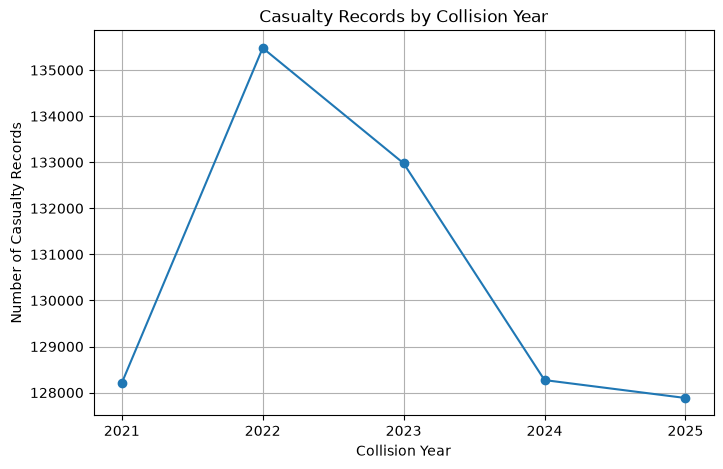

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    year_summary.index,
    year_summary["Count"],
    marker="o"
)

plt.title("Casualty Records by Collision Year")
plt.xlabel("Collision Year")
plt.ylabel("Number of Casualty Records")
plt.xticks(year_summary.index)
plt.grid(True)

plt.show()

## 8. Geographic Analysis

This step examines the geographic information available in the Casualty dataset.

The `lsoa_of_casualty` variable identifies the Lower Layer Super Output Area (LSOA) associated with the casualty location. The analysis focuses on geographic coverage, the number of unique LSOA areas, and the presence of unknown or unavailable geographic codes.

No data values are modified during this EDA stage.

In [29]:
print("Unique LSOA values:", casualty_df["lsoa_of_casualty"].nunique())

Unique LSOA values: 36519


In [30]:
casualty_df["lsoa_of_casualty"].value_counts().head(20)

lsoa_of_casualty
-1           95560
E01019456      195
E01003666      111
E01001087       96
E01033583       93
E01002040       82
E01003221       80
E01000524       79
E01000521       76
E01002071       76
E01000171       76
E01000508       76
E01000472       75
E01000523       73
E01021544       73
E01025224       73
E01000506       73
E01002048       72
E01002051       72
E01000092       71
Name: count, dtype: int64

### 8.2 Unknown / Missing Geographic Codes

The `lsoa_of_casualty` variable contains geographic identifiers representing Lower Layer Super Output Areas (LSOAs), which are small statistical geographic areas used in the UK. Valid LSOA identifiers in the dataset typically follow the `E010...` format, where each code identifies a specific geographic area.

The value `-1` does not represent a geographic area. It is treated separately as a coded value indicating that the LSOA information is unavailable or unknown.

Therefore, the analysis distinguishes between valid LSOA identifiers and the `-1` coded value. The number and percentage of records containing `-1` are calculated to assess the extent of unavailable geographic information.

No geographic values are modified or removed during this EDA stage.

In [31]:
unknown_lsoa_count = (casualty_df["lsoa_of_casualty"] == -1).sum()

unknown_lsoa_percentage = (
    unknown_lsoa_count / len(casualty_df) * 100
)

print("Unknown LSOA Count:", unknown_lsoa_count)
print("Unknown LSOA Percentage:", round(unknown_lsoa_percentage, 2), "%")

Unknown LSOA Count: 0
Unknown LSOA Percentage: 0.0 %


### 8.3 Geographic Analysis — Findings

The `lsoa_of_casualty` variable contains 36,519 unique values, representing geographic areas identified using LSOA codes.

The most frequently occurring value in the dataset is `-1`, with 95,560 records. However, the calculation of unknown geographic values using `(lsoa_of_casualty == -1)` returned 0 records. This indicates that the `-1` value is stored as a string rather than as a numeric value.

Therefore, the `-1` value must be treated as a string-coded value when performing missing or unavailable geographic analysis.

The remaining values follow the `E010...` format and represent LSOA geographic identifiers.

No geographic values are removed or modified during this EDA stage. The identified coded value will be considered during later data preprocessing.

In [32]:
unknown_lsoa_count = (casualty_df["lsoa_of_casualty"] == "-1").sum()

unknown_lsoa_percentage = (
    unknown_lsoa_count / len(casualty_df) * 100
)

print("Unknown LSOA Count:", unknown_lsoa_count)
print("Unknown LSOA Percentage:", round(unknown_lsoa_percentage, 2), "%")

Unknown LSOA Count: 95560
Unknown LSOA Percentage: 14.64 %


### 8.3 Geographic Analysis — Findings

The `lsoa_of_casualty` variable contains 36,519 unique values. The valid geographic identifiers follow the `E010...` format and represent specific Lower Layer Super Output Areas (LSOAs).

A total of 95,560 records contain the coded value `-1`, representing unavailable or unknown LSOA information. This accounts for 14.64% of all casualty records.

Therefore, although the dataset contains substantial geographic coverage, approximately 14.64% of casualty records do not have an available LSOA identifier.

The `-1` coded values should be considered during later data preprocessing and integration. No records are removed or modified during this EDA stage.

## 9. Special / Unknown Code Analysis

This step examines coded values used in the Casualty dataset to represent missing, unknown, unavailable, out-of-range, or other special categories.

Values such as `-1`, `9`, and `99` do not have a universal meaning across the dataset. Their interpretation is variable-specific and therefore must be considered using the official STATS19 variable definitions.

This analysis identifies the frequency of relevant special codes and documents their meanings before data preprocessing.

No values are removed or modified during this EDA stage.

### 9.1 Variables Containing the `-1` Code

The `-1` code is examined across the Casualty dataset to identify variables where it occurs and determine the extent of coded unavailable, missing, or out-of-range values.

The meaning of `-1` is variable-specific and is not assumed to be the same across all columns.

In [33]:
minus_one_summary = []

for column in casualty_df.columns:
    count = (casualty_df[column] == -1).sum()
    if count > 0:
        minus_one_summary.append({
            "Column": column,
            "Count": count,
            "Percentage": round(count / len(casualty_df) * 100, 2)
        })

minus_one_summary = pd.DataFrame(minus_one_summary)

display(
    minus_one_summary.sort_values(
        "Percentage",
        ascending=False
    )
)

,Column,Count,Percentage
11,casualty_distance_banding,428604,65.65
10,enhanced_casualty_severity,226536,34.70
9,casualty_imd_decile,73236,11.22
7,pedestrian_road_maintenance_worker,29440,4.51
2,age_band_of_casualty,14106,2.16
1,age_of_casualty,14106,2.16
0,sex_of_casualty,6304,0.97
8,casualty_type,5780,0.89
5,car_passenger,2926,0.45
6,bus_or_coach_passenger,515,0.08


### 9.1 `-1` Code — Findings

The `-1` code occurs in multiple Casualty dataset variables, but its meaning is variable-specific according to the STATS19 definitions.

The highest occurrence is in `casualty_distance_banding`, where 428,604 records (65.65%) contain `-1`. This is followed by `enhanced_casualty_severity` with 226,536 records (34.70%) and `casualty_imd_decile` with 73,236 records (11.22%).

Other variables contain smaller proportions of `-1` values, including `pedestrian_road_maintenance_worker` (4.51%), `age_band_of_casualty` and `age_of_casualty` (2.16%), `sex_of_casualty` (0.97%), and `casualty_type` (0.89%).

The presence of `-1` does not automatically indicate the same condition across all variables. Therefore, these coded values will be interpreted according to their individual variable definitions during later preprocessing.

No values are removed or modified during this EDA stage.

### 9.2 String-Coded `-1` Values

Some variables in the Casualty dataset are stored as strings rather than numeric values. Therefore, coded values such as `"-1"` must be examined separately from numeric `-1` values.

The `lsoa_of_casualty` variable contains the string-coded value `"-1"`, representing unavailable or unknown geographic information. Its frequency and percentage are examined separately.

In [34]:
unknown_lsoa_count = (casualty_df["lsoa_of_casualty"] == "-1").sum()

unknown_lsoa_percentage = (
    unknown_lsoa_count / len(casualty_df) * 100
)

print("String '-1' Count:", unknown_lsoa_count)
print("String '-1' Percentage:", round(unknown_lsoa_percentage, 2), "%")

String '-1' Count: 95560
String '-1' Percentage: 14.64 %


### 9.3 Other Special Codes (`9` and `99`)

The values `9` and `99` are examined separately because they do not have a universal meaning across the Casualty dataset.

Their interpretation depends on the specific variable. For example, in some variables, `9` represents an unknown or self-reported category, while `99` may represent an unknown or unspecified category.

Therefore, the frequency of these codes is identified for each variable rather than treating them automatically as missing values.

No values are removed or modified during this EDA stage.

In [35]:
special_9_summary = []

for column in casualty_df.columns:
    count = (casualty_df[column] == 9).sum()
    
    if count > 0:
        special_9_summary.append({
            "Column": column,
            "Count": count,
            "Percentage": round(count / len(casualty_df) * 100, 2)
        })

special_9_summary = pd.DataFrame(special_9_summary)

display(
    special_9_summary.sort_values(
        "Percentage",
        ascending=False
    )
)

,Column,Count,Percentage
9,casualty_type,347393,53.21
4,age_band_of_casualty,64371,9.86
10,casualty_imd_decile,44577,6.83
6,pedestrian_movement,27230,4.17
5,pedestrian_location,9709,1.49
3,age_of_casualty,3477,0.53
7,car_passenger,679,0.10
1,casualty_reference,137,0.02
2,sex_of_casualty,129,0.02
8,bus_or_coach_passenger,107,0.02


### 9.3 Other Special Code `9` — Findings

The value `9` occurs in several Casualty dataset variables, but its meaning differs according to the variable definition.

The highest occurrence is in `casualty_type`, where 347,393 records (53.21%) have the value `9`. In this variable, code `9` represents a car occupant and is therefore a valid category rather than a missing or unknown value.

The value `9` also occurs in `age_band_of_casualty` (9.86%) and `casualty_imd_decile` (6.83%), where it represents valid categories rather than missing information.

In contrast, `9` represents an unknown or self-reported category in some variables such as `sex_of_casualty`, `car_passenger`, and `bus_or_coach_passenger`.

Therefore, the value `9` must be interpreted according to the specific variable definition and must not be globally classified as a missing value.

No values are removed or modified during this EDA stage.

### 9.4 Code `99`

The value `99` is examined across the Casualty dataset to identify variables where it occurs and determine its frequency.

As with `-1` and `9`, the meaning of `99` is variable-specific. Therefore, its presence is documented without automatically treating it as a missing value.

In [36]:
special_99_summary = []

for column in casualty_df.columns:
    count = (casualty_df[column] == 99).sum()
    
    if count > 0:
        special_99_summary.append({
            "Column": column,
            "Count": count,
            "Percentage": round(count / len(casualty_df) * 100, 2)
        })

special_99_summary = pd.DataFrame(special_99_summary)

display(
    special_99_summary.sort_values(
        "Percentage",
        ascending=False
    )
)

,Column,Count,Percentage
2,casualty_type,33,0.01
0,casualty_reference,2,0.00
1,age_of_casualty,18,0.00


### 9.4 Code `99` — Findings

The value `99` occurs in only three variables in the Casualty dataset.

The highest occurrence is in `casualty_type`, with 33 records (0.01%). It also occurs in `age_of_casualty` with 18 records and `casualty_reference` with 2 records, both representing less than 0.01% of the dataset.

The meaning of code `99` is variable-specific and therefore it is not treated as a universal missing-value indicator.

The very low frequency of these values indicates that code `99` has limited influence on the overall Casualty dataset distribution. These records will be considered during later preprocessing according to the definition of each variable.

No values are removed or modified during this EDA stage.

### 9.5 Special-Code Analysis — Summary

The Casualty dataset contains several coded values that require variable-specific interpretation. The values `-1`, `9`, and `99` do not have a universal meaning across all variables.

According to the STATS19 data definitions, `-1` commonly represents data that are missing or out of range for variables such as `age_of_casualty`, `sex_of_casualty`, `casualty_imd_decile`, and `casualty_distance_banding`. However, codes such as `9` may represent either a valid category or an unknown/self-reported value depending on the variable. For example, `age_band_of_casualty = 9` represents the 56–65 age group, while `sex_of_casualty = 9` represents an unknown self-reported value.

Similarly, `casualty_type = 9` represents a car occupant and is therefore a valid category, whereas `casualty_type = 99` represents an unknown vehicle type reported by the data source.

The analysis therefore confirms that special codes must be interpreted at the individual variable level rather than being globally treated as missing values.

These coded values will be handled appropriately during the later data preprocessing stage. No values are removed or modified during this EDA stage.

## 10. Casualty EDA — Overall Findings and Data Quality Summary

The exploratory analysis of the Casualty dataset identified several characteristics that should be considered during subsequent data preprocessing and feature engineering.

The dataset contains 652,821 casualty-level records covering the years 2021–2025. No actual `NaN` values were found across the 23 variables; however, several variables contain coded values representing missing, unavailable, unknown, or special categories.

The main findings identified during the EDA are summarized below:

1. **Coded missing and special values**
   - Several variables contain `-1`, `9`, or `99` codes.
   - These codes have variable-specific meanings and cannot be treated as universally missing.
   - For example, `age_band_of_casualty = 9` represents a valid age category, whereas `sex_of_casualty = 9` represents an unknown self-reported value.

2. **Geographic information**
   - The `lsoa_of_casualty` variable contains 36,519 unique values.
   - A total of 95,560 records (14.64%) contain the string-coded value `"-1"`, representing unavailable or unknown LSOA information.

3. **Age values**
   - `age_of_casualty` contains coded `-1` values and a small number of statistically unusual high ages.
   - After excluding the coded `-1` values, 446 records (0.07%) were identified as IQR-based statistical outliers.
   - These observations are not automatically considered errors.

4. **Adjusted severity variables**
   - `casualty_adjusted_severity_serious` and `casualty_adjusted_severity_slight` contain values between 0 and 1 with many fractional values.
   - The IQR method identified a relatively large number of statistical outliers because these variables have highly concentrated and bounded distributions.
   - These values should therefore not be automatically removed based solely on the IQR method.

5. **Temporal coverage**
   - All five study years from 2021 to 2025 are represented.
   - The yearly distribution of casualty records is relatively consistent, with percentages ranging from 19.59% to 20.75%.
   - The Casualty dataset does not contain direct date or time fields, so detailed temporal analysis will rely on the Collision dataset during integration.

6. **Categorical distributions**
   - Several categorical variables have highly dominant categories, such as `casualty_type`, `pedestrian_location`, `pedestrian_movement`, and `bus_or_coach_passenger`.
   - These distributions should be considered during later feature encoding and modelling.

7. **Identifier-like variables**
   - `vehicle_reference` and `casualty_reference` are reference identifiers rather than continuous numerical measurements.
   - They should not be treated as ordinary numerical features during modelling.

No records or values were removed, modified, or transformed during the EDA stage. The identified issues will be addressed during the subsequent data preprocessing and feature engineering stages.